# Plot elevdep of biases

In [1]:
import os
import xarray as xr
import pandas as pd
import geopandas as gpd
import plotnine as p9
import mizani
from plotnine import (
    ggplot, aes, 
    geom_point, geom_line, geom_raster, geom_tile, geom_path, geom_vline,
    facet_wrap, facet_grid,
    coord_equal,
    xlim, ylim, ggtitle, xlab, ylab,
    scale_fill_distiller, scale_fill_gradient2, scale_color_manual,
    theme, element_blank, element_text
)
import regionmask

ERROR 1: PROJ: proj_create_from_database: Open of /mnt/CORDEX_CMIP6_tmp/user_tmp/mmatiu/conda_envs/jsc/share/proj failed


## settings and data-prep

In [2]:
variable = "tasmax"
elev_bins = 200

path_fig = os.path.abspath(os.path.join(os.getcwd(), "..", "fig/elevdep"))
os.makedirs(path_fig, exist_ok=True)

In [3]:
gpd_regions = gpd.read_file("../data/regions.gpkg")
regions = regionmask.Regions.from_geodataframe(gpd_regions)

In [4]:
eur_colors = pd.read_csv("eurocordex_models.csv")

In [5]:
xds = xr.open_dataset("../intermediate-results/" + variable + "_CMIP6_1991-2020_spatial_bias.nc")
df = xds.to_dataframe().reset_index()

In [6]:
mask = regions.mask_3D(xds["lon"], xds["lat"], drop=False)
df_mask = mask.to_dataframe().reset_index()
df_mask_tosubset = df_mask[["region", "rlat", "rlon", "names", "mask"]][df_mask["mask"]]

In [7]:
xds_orog = xr.open_dataset("../intermediate-results/orog.nc")
df_orog = xds_orog.to_dataframe().reset_index()
df_orog2 = df_orog[["rlat", "rlon", "dset_id", "orog"]]

In [8]:
df_regions = pd.merge(df, df_mask_tosubset).dropna()
df_regions_orog = pd.merge(df_regions, df_orog2)

In [9]:
# df_regions_mm = df_regions.groupby(["season","rlat","rlon","region","names"])[[variable]].mean()
# df_regions_mm = df_regions_mm.reset_index()

In [10]:
[df_regions_orog["orog"].min(), df_regions_orog["orog"].max()]

[np.float32(-15.448828), np.float32(3059.1768)]

In [11]:
elev_breaks = [-20, *list(range(elev_bins, 3100-elev_bins, elev_bins)), 3100]

In [12]:
df_regions_orog["elev_grp"] = pd.cut(
    df_regions_orog["orog"],
    bins=pd.IntervalIndex.from_breaks(elev_breaks)
)

In [13]:
df_elevdep = df_regions_orog.groupby(
    ["dset_id", "season", "names", "elev_grp"],
    as_index=False
)[variable].mean()


<positron-console-cell-13>:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


## plots

In [14]:
df_plot = df_elevdep.dropna()
df_plot["season_cat"] = pd.Categorical(
    df_plot["season"], categories=['DJF', 'MAM', 'JJA', 'SON']
)

<positron-console-cell-14>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [15]:
# (
#     ggplot(df_plot, aes("tasmax", "elev_grp"))
#     # + geom_point()
#     + geom_vline(xintercept = 0, linetype="dashed")
#     + geom_path(aes(group="dset_id"), colour="grey")
#     + facet_grid("season_cat ~ names")
#     + p9.theme_bw(6)
#     + xlab(variable + " bias")
#     + ylab("Elevation")
# )

In [16]:
criterion = eur_colors["model"].map(lambda x: x in df_plot["dset_id"].unique())
eur_colors2 = eur_colors[criterion]
col_dict = dict(zip(eur_colors2["model"], eur_colors2["color"]))

In [17]:
if variable == "pr":
    xl = variable + " bias [%]"
else:
    xl = variable + " bias [°C]"

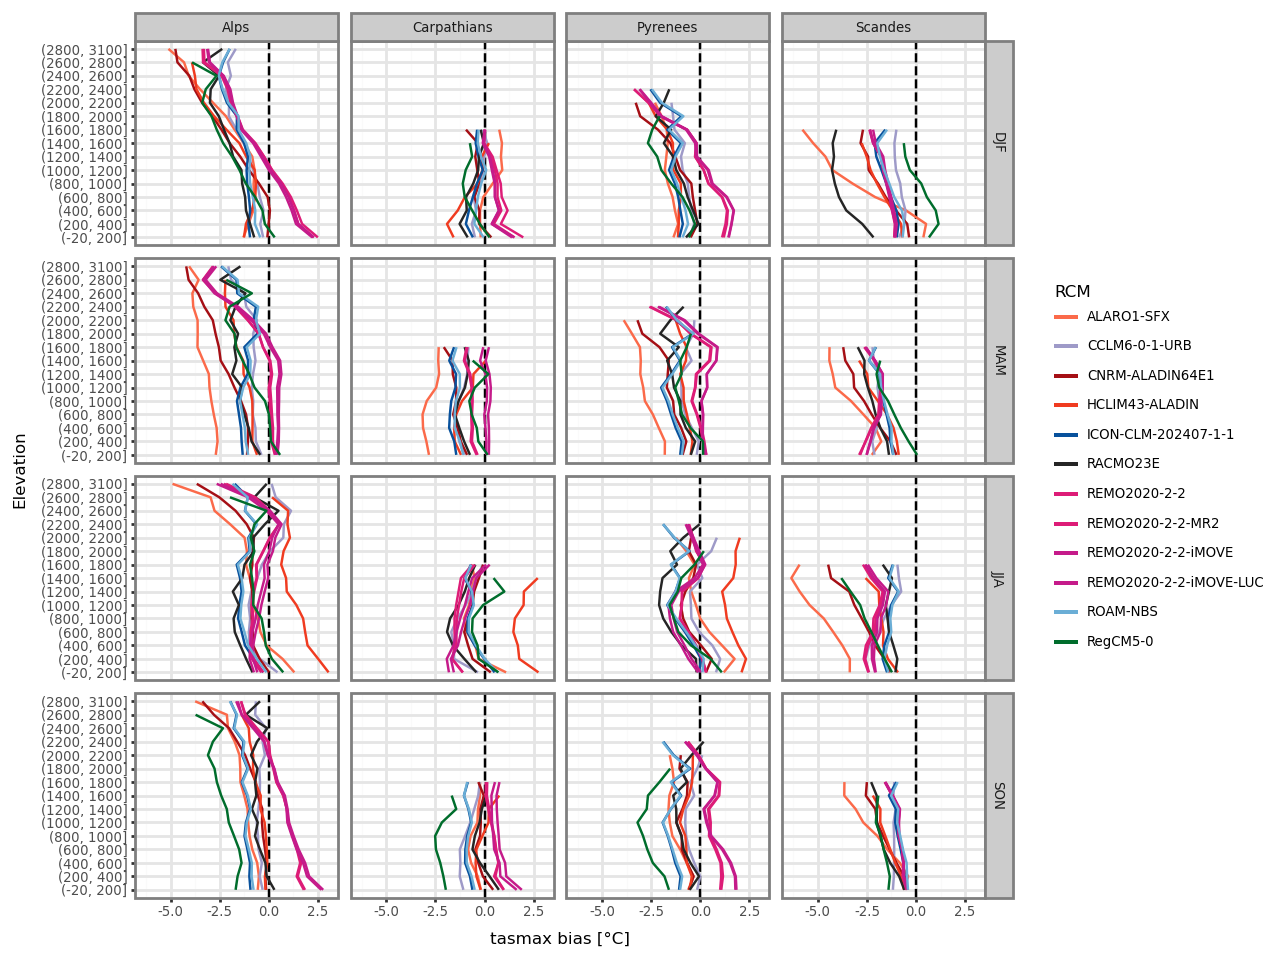

In [18]:
gg = (
    ggplot(df_plot, aes("tasmax", "elev_grp", colour="dset_id"))
    # + geom_point()
    + geom_vline(xintercept = 0, linetype="dashed")
    + geom_path(aes(group="dset_id"))
    + facet_grid("season_cat ~ names")
    + scale_color_manual(values=col_dict,name="RCM")
    + p9.theme_bw(6)
    + xlab(xl)
    + ylab("Elevation")
)

gg.show()
filepath_save = f"{path_fig}/{variable}_single-model.png"
gg.save(filepath_save, width=8, height=6, dpi=300, verbose=False)

In [19]:
# (
#     ggplot(df1[df1["region"]==0], aes("rlon","rlat",fill="tas"))
#     + geom_raster()
#     # + scale_fill_distiller(type="div", limits=[-5,5], direction=-1)
#     + scale_fill_gradient2(mid="#f5f5f5", high="#d73027", low="#4575b4")
#     # + scale_fill_gradient2()
#     + facet_wrap("season")
#     + theme_bw()
#     + ggtitle(regions[0].name)
# )

In [20]:
# gg = (
#     ggplot(df_tas_regions[(df_regions["region"]==0) & 
#                           (df_regions["season"]=="DJF")], 
#            aes("rlon","rlat",fill=variable))
#     + geom_raster()
#     + scale_fill_gradient2(name = variable + "\n bias \n E-OBS", 
#                            mid="#f5f5f5", high="#d73027", low="#4575b4")
#     # + facet_grid("season", "dset_id")
#     + facet_wrap("dset_id")
#     + coord_equal()
#     + theme_bw()
#     + theme(axis_title=element_blank(), 
#             axis_ticks=element_blank(), 
#             axis_text=element_blank())
#     + ggtitle(regions[0].name)
# )
# gg.show()
# # gg.save("test.png", width=12, height=8, dpi=300)